In [1]:
#data handling
import pandas as pd
import pandas as pd

In [2]:
#visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [3]:
#test processing
import nltk
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [4]:
#machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
#download nltk data
import nltk
nltk.download('punkt')  
nltk.download('stopwords')
nltk.download('wordnet')    
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\devs4\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\devs4\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\devs4\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\devs4\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [6]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
#If using Sentiment140 dataset, it may not have headers:
df = pd.read_csv('training.1600000.processed.noemoticon.csv', encoding='latin-1', header=None, names=['target', 'id', 'date', 'flag', 'user', 'text'])
print('Dataset downloaded')
print(f"shape:{df.shape}")
df.head()

Dataset downloaded
shape:(1048575, 6)


,target,id,date,flag,user,text
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1048575 non-null  int64 
 1   id      1048575 non-null  int64 
 2   date    1048575 non-null  object
 3   flag    1048575 non-null  object
 4   user    1048575 non-null  object
 5   text    1048575 non-null  object
dtypes: int64(2), object(4)
memory usage: 48.0+ MB
None


In [9]:
print(df.isnull().sum())

target    0
id        0
date      0
flag      0
user      0
text      0
dtype: int64


In [10]:
print(df.describe())

             target            id
count  1.048575e+06  1.048575e+06
mean   9.482431e-01  1.976166e+09
std    1.701120e+00  2.300580e+08
min    0.000000e+00  1.467811e+09
25%    0.000000e+00  1.824526e+09
50%    0.000000e+00  1.990869e+09
75%    0.000000e+00  2.198903e+09
max    4.000000e+00  2.329206e+09


In [11]:
print("\n=== Sentiment Distribution ===")
print(df['target'].value_counts())


=== Sentiment Distribution ===
target
0    799999
4    248576
Name: count, dtype: int64


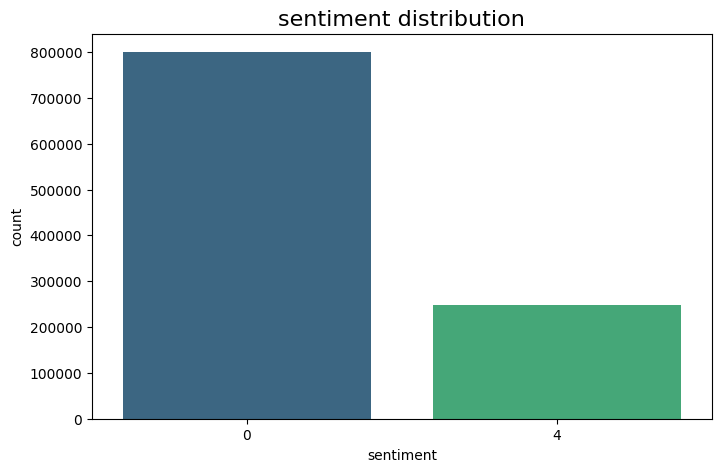

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('sentiment distribution', fontsize=16)
plt.xlabel('sentiment')
plt.ylabel('count')
plt.show()

In [13]:
df['text_length']=df['text'].apply(len)

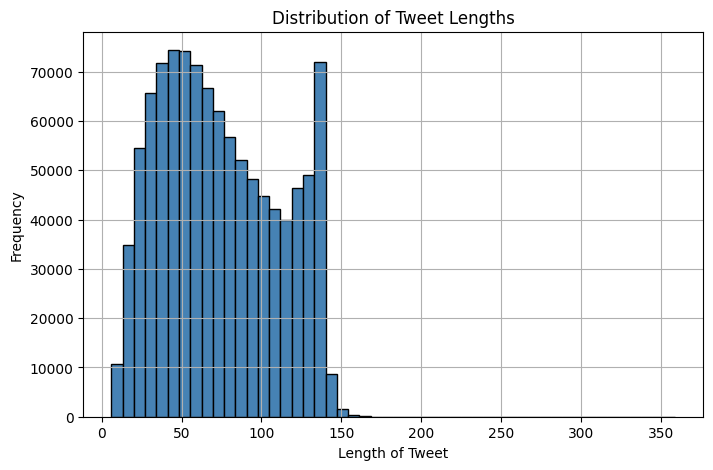

In [14]:
plt.figure(figsize=(8, 5))
df['text_length'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Tweet Lengths')
plt.xlabel('Length of Tweet')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Initialize tools
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_tweet(text):
    """
    This function takes a raw tweet and returns a cleaned version.
    """

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove URLs (http, https, www)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Remove @mentions
    text = re.sub(r'@\w+', '', text)

    # 4. Remove hashtag symbol (keep the word)
    text = re.sub(r'#', '', text)

    # 5. Remove RT (retweet indicator)
    text = re.sub(r'^rt[\s]+', '', text)

    # 6. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 7. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 8. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 9. Tokenize (split into individual words)
    tokens = word_tokenize(text)

    # 10. Remove stopwords and apply lemmatization
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2  # Also remove very short words
    ]

    # 11. Join tokens back into a string
    return ' '.join(cleaned_tokens)

#Apply Preprocessing to ALL tweets 
print("⏳ Preprocessing tweets... (this may take a few minutes)")
df['cleaned_text'] = df['text'].apply(preprocess_tweet)
print("✅ Preprocessing complete!")

#See Before vs After
print("\n=== BEFORE Cleaning ===")
print(df['text'].iloc[0])
print("\n=== AFTER Cleaning ===")
print(df['cleaned_text'].iloc[0])

⏳ Preprocessing tweets... (this may take a few minutes)


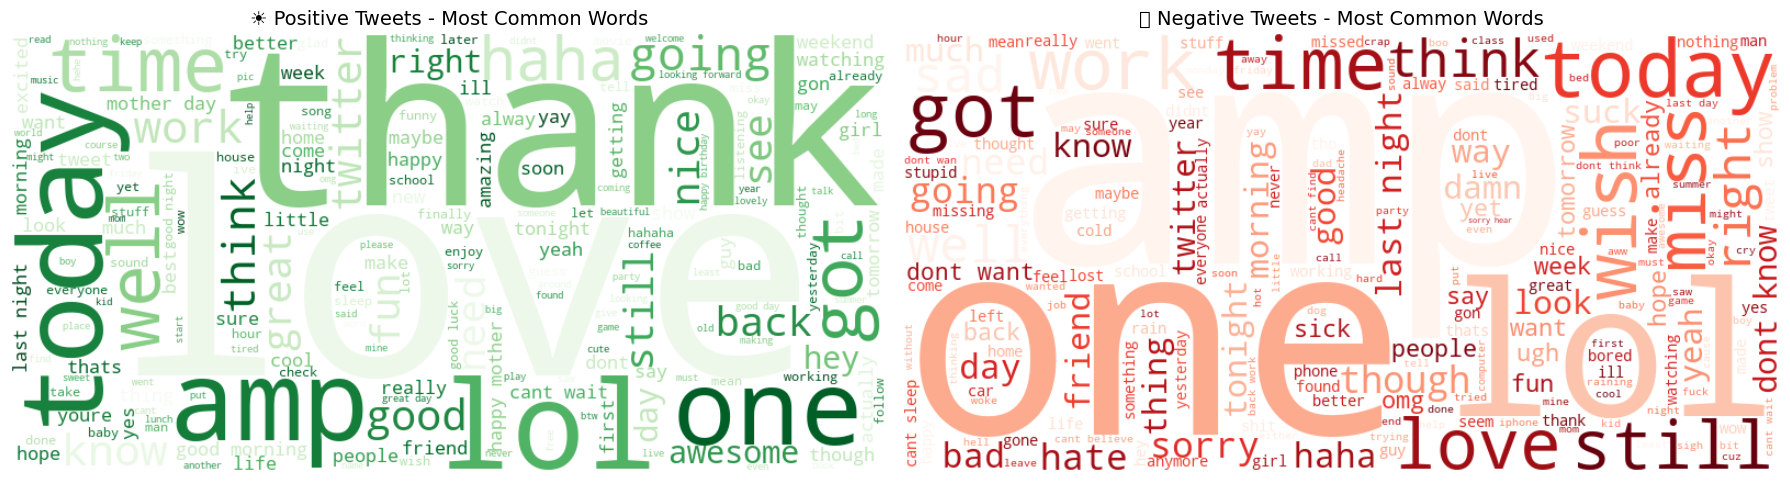

In [ ]:
#Word Cloud for Positive Tweets
positive_text = ' '.join(df[df['target'] == 4]['cleaned_text'])  # 4 = Positive
negative_text = ' '.join(df[df['target'] == 0]['cleaned_text'])  # 0 = Negative

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Positive Word Cloud
wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=200).generate(positive_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('☀️ Positive Tweets - Most Common Words', fontsize=14)
axes[0].axis('off')

# Negative Word Cloud
wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', max_words=200).generate(negative_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('🌧️ Negative Tweets - Most Common Words', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#feature extraction
tfidf = TfidfVectorizer(max_features=5000)
X=tfidf.fit_transform(df['cleaned_text'])
y=df['target']
print(f"featire matrix shape:{X.shape}")

featire matrix shape:(1048575, 5000)


In [ ]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]}")
print(f"Training set size: {X_test.shape[0]}")

Training set size: 838860
Training set size: 209715


In [ ]:
#model training using Logistic Regression
print("Training Logistic Regression")
lr_model=LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred=lr_model.predict(X_test)
lr_acc=accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy : {lr_acc*100:.2f}%\n")

Training Logistic Regression
Logistic Regression Accuracy : 83.07%



In [ ]:
#model tranining using Naive Bayes
print("Training Naive Bayes")
nb_model=MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred=nb_model.predict(X_test)
nb_acc=accuracy_score(y_test, nb_pred)
print(f"Naive Bayes Accuracy : {nb_acc*100:.2f}%\n")

Training Naive Bayes
Naive Bayes Accuracy : 80.48%



In [ ]:
#model Support Vector Machine 
print("Training SVM")
svm_model = LinearSVC(max_iter=2000)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)
print(f"SVM Accuracy: {svm_acc * 100:.2f}%\n")

Training SVM
SVM Accuracy: 82.94%



In [ ]:
#Compare All Models
print("=" * 40)
print("MODEL COMPARISON")
print("=" * 40)
print(f"Logistic Regression : {lr_acc * 100:.2f}%")
print(f"Naive Bayes         : {nb_acc * 100:.2f}%")
print(f"SVM                 : {svm_acc * 100:.2f}%")

MODEL COMPARISON
Logistic Regression : 83.07%
Naive Bayes         : 80.48%
SVM                 : 82.94%


CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.85      0.94      0.89    160000
    Positive       0.72      0.47      0.57     49715

    accuracy                           0.83    209715
   macro avg       0.79      0.71      0.73    209715
weighted avg       0.82      0.83      0.82    209715



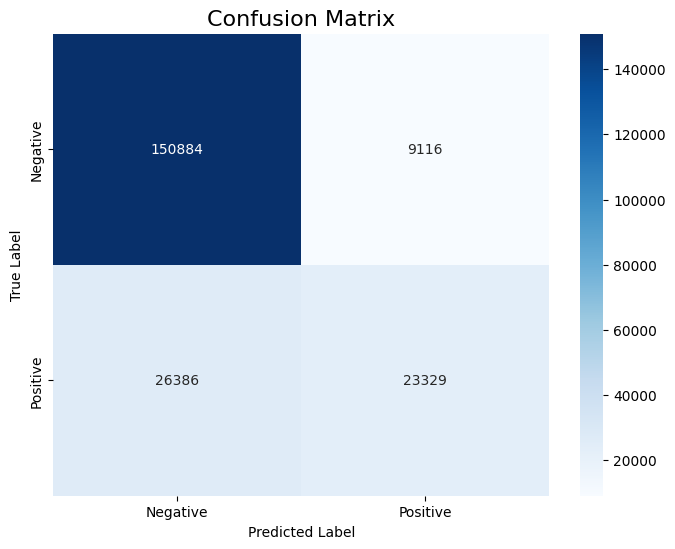

In [ ]:
# Let's say Logistic Regression was the best — evaluate it in detail
# Replace lr_pred with whichever model performed best

best_pred = lr_pred  # Change this to nb_pred or svm_pred if needed

#Classification Report 
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, best_pred, target_names=['Negative', 'Positive']))

# ---- Confusion Matrix ----
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
def predict_sentiment(tweet):
    """
    Takes a raw tweet string, cleans it, and predicts sentiment.
    """
    # Step 1: Clean the tweet
    cleaned = preprocess_tweet(tweet)

    # Step 2: Convert to TF-IDF vector
    vectorized = tfidf.transform([cleaned])

    # Step 3: Predict
    prediction = lr_model.predict(vectorized)[0]  # Use your best model

    # Step 4: Return result
    if prediction == 4:
        return "POSITIVE"
    elif prediction == 0:
        return "NEGATIVE"
    else:
        return "NEUTRAL"

# ---- Try it out! ----
test_tweets = [
    "I love this beautiful day! The sun is shining!",
    "This is the worst experience ever. Totally disappointed.",
    "Just had an amazing coffee at the new café downtown!",
    "I hate waiting in long lines. So frustrating!",
    "The movie was okay, nothing special."
]

print("=" * 60)
print("SENTIMENT PREDICTIONS")
print("=" * 60)
for tweet in test_tweets:
    sentiment = predict_sentiment(tweet)
    print(f"\nTweet: {tweet}")
    print(f"Sentiment: {sentiment}")

SENTIMENT PREDICTIONS

Tweet: I love this beautiful day! The sun is shining!
Sentiment: POSITIVE

Tweet: This is the worst experience ever. Totally disappointed.
Sentiment: NEGATIVE

Tweet: Just had an amazing coffee at the new café downtown!
Sentiment: POSITIVE

Tweet: I hate waiting in long lines. So frustrating!
Sentiment: NEGATIVE

Tweet: The movie was okay, nothing special.
Sentiment: NEGATIVE


In [ ]:
import pickle

# Save the model
with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

# Save the vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Model and Vectorizer saved!")


Model and Vectorizer saved!
